In [34]:
import pandas as pd
train = pd.read_csv("santanderdataset/train.csv")
test = pd.read_csv("santanderdataset/test.csv")

In [35]:
print(train.head())
print(train.shape)
print(train.info())
print(train.describe())

   ID_code  target    var_0   var_1    var_2   var_3    var_4   var_5   var_6  \
0  train_0       0   8.9255 -6.7863  11.9081  5.0930  11.4607 -9.2834  5.1187   
1  train_1       0  11.5006 -4.1473  13.8588  5.3890  12.3622  7.0433  5.6208   
2  train_2       0   8.6093 -2.7457  12.0805  7.8928  10.5825 -9.0837  6.9427   
3  train_3       0  11.0604 -2.1518   8.9522  7.1957  12.5846 -1.8361  5.8428   
4  train_4       0   9.8369 -1.4834  12.8746  6.6375  12.2772  2.4486  5.9405   

     var_7  ...  var_190  var_191  var_192  var_193  var_194  var_195  \
0  18.6266  ...   4.4354   3.9642   3.1364   1.6910  18.5227  -2.3978   
1  16.5338  ...   7.6421   7.7214   2.5837  10.9516  15.4305   2.0339   
2  14.6155  ...   2.9057   9.7905   1.6704   1.6858  21.6042   3.1417   
3  14.9250  ...   4.4666   4.7433   0.7178   1.4214  23.0347  -1.2706   
4  19.2514  ...  -1.4905   9.5214  -0.1508   9.1942  13.2876  -1.5121   

   var_196  var_197  var_198  var_199  
0   7.8784   8.5635  12.7803  -1.0

In [36]:
print(train.isnull().sum())

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64


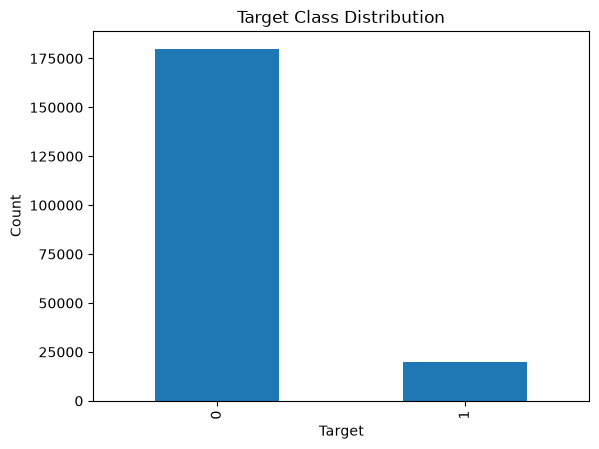

In [37]:
import matplotlib.pyplot as plt

train["target"].value_counts().plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [38]:
train["target"].value_counts()
train["target"].value_counts(normalize=True) * 100

target
0    89.951
1    10.049
Name: proportion, dtype: float64

In [39]:
X = train.drop(["ID_code", "target"], axis=1)
y = train["target"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [44]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.9134
Precision: 0.682175622542595
Recall: 0.258955223880597
F1 Score: 0.3754056978002164
[[35495   485]
 [ 2979  1041]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.68      0.26      0.38      4020

    accuracy                           0.91     40000
   macro avg       0.80      0.62      0.66     40000
weighted avg       0.90      0.91      0.90     40000



In [45]:
# BALANCING THE CLASSES
class_weight="balanced"
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.7834
Precision: 0.2865416436845008
Recall: 0.7753731343283582
F1 Score: 0.4184454289166331
[[28219  7761]
 [  903  3117]]
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000



In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid = GridSearchCV(
    LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall:", grid.best_score_)

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best Recall: 0.7808800670055631


In [48]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

Accuracy: 0.777975
Precision: 0.2819592715528842
Recall: 0.7818407960199005
F1 Score: 0.4144524296169315
[[27976  8004]
 [  877  3143]]


In [50]:
"""BaseExceptionGroupfrom sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)"""

'BaseExceptionGroupfrom sklearn.preprocessing import PolynomialFeatures\n\npoly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)\n\nX_train_poly = poly.fit_transform(X_train)\nX_test_poly = poly.transform(X_test)'

In [51]:
"""model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_poly, y_train)

predictions = model.predict(X_test_poly)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))"""

'model = LogisticRegression(\n    class_weight="balanced",\n    random_state=42,\n    max_iter=1000\n)\n\nmodel.fit(X_train_poly, y_train)\n\npredictions = model.predict(X_test_poly)\n\nfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score\n\nprint("Accuracy:", accuracy_score(y_test, predictions))\nprint("Precision:", precision_score(y_test, predictions))\nprint("Recall:", recall_score(y_test, predictions))\nprint("F1:", f1_score(y_test, predictions))'

In [52]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)

X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)

model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_new, y_train)

predictions = model.predict(X_test_new)

In [53]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))

Accuracy: 0.7701
Precision: 0.27081119376549767
Recall: 0.7606965174129353
F1: 0.3994252873563218


In [54]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)
model = LogisticRegression(random_state=42,max_iter=1000)
model.fit(X_train_smote,y_train_smote)
predictions = model.predict(X_test)


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

Accuracy : 0.78945
Precision: 0.29077946768060836
Recall   : 0.7609452736318408
F1 Score : 0.42077028885832185
[[28519  7461]
 [  961  3059]]


In [57]:
#gridsearch along with class balancing and smote
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid = GridSearchCV(
    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'C': 0.0001, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Recall: 0.8442488804262072


In [58]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

Accuracy : 0.761
Precision: 0.2680843938379103
Recall   : 0.7965174129353234
F1 Score : 0.40115259333500375
[[27238  8742]
 [  818  3202]]


In [59]:
probabilities = best_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for t in thresholds:
    preds = (probabilities >= t).astype(int)

    print(f"\nThreshold = {t}")
    print("Recall   :", recall_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("F1 Score :", f1_score(y_test, preds))


Threshold = 0.5
Recall   : 0.7965174129353234
Precision: 0.2680843938379103
F1 Score : 0.40115259333500375

Threshold = 0.45
Recall   : 0.8388059701492537
Precision: 0.24044495151169423
F1 Score : 0.3737530481046331

Threshold = 0.4
Recall   : 0.8743781094527363
Precision: 0.21466959814339806
F1 Score : 0.34470922820437383

Threshold = 0.35
Recall   : 0.9049751243781095
Precision: 0.1923239585536054
F1 Score : 0.317230554586676

Threshold = 0.3
Recall   : 0.9313432835820895
Precision: 0.17343771714457776
F1 Score : 0.29242004139493105

Threshold = 0.25
Recall   : 0.9532338308457712
Precision: 0.1561277705345502
F1 Score : 0.2683097605377398

Threshold = 0.2
Recall   : 0.9711442786069652
Precision: 0.14060361593315565
F1 Score : 0.2456427357956333
